<p style="color:#824AE8;font-family:Ubuntu Light;font-size:140%">DATA SCIENCE IN CHEMISTRY</p>

# Data Analytics with RDKit PandasTools

In [1]:
from rdkit import Chem
from rdkit.Chem import Descriptors, PandasTools
import pandas as pd

## Loading SDF into a pandas dataframe

### - PandasTools.LoadSDF

In [4]:
df = PandasTools.LoadSDF("pubchem_molecules.sdf", molColName = None)

In [5]:
df

,PUBCHEM_COMPOUND_CID,PUBCHEM_COMPOUND_CANONICALIZED,PUBCHEM_CACTVS_COMPLEXITY,PUBCHEM_CACTVS_HBOND_ACCEPTOR,PUBCHEM_CACTVS_HBOND_DONOR,PUBCHEM_CACTVS_ROTATABLE_BOND,PUBCHEM_CACTVS_SUBSKEYS,PUBCHEM_IUPAC_OPENEYE_NAME,PUBCHEM_IUPAC_CAS_NAME,PUBCHEM_IUPAC_NAME_MARKUP,...,PUBCHEM_ATOM_UDEF_STEREO_COUNT,PUBCHEM_BOND_DEF_STEREO_COUNT,PUBCHEM_BOND_UDEF_STEREO_COUNT,PUBCHEM_ISOTOPIC_ATOM_COUNT,PUBCHEM_COMPONENT_COUNT,PUBCHEM_CACTVS_TAUTO_COUNT,PUBCHEM_COORDINATE_TYPE,ID,PUBCHEM_XLOGP3,PUBCHEM_BONDANNOTATIONS
0,297,1,0,0,0,0,AAADcYAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,methane,methane,methane,...,0,0,0,0,1,-1,1\n5\n255,297,NaN,NaN
1,2244,1,212,4,1,3,AAADccBwOAAAAAAAAAAAAAAAAAAAAAAAAAAwAAAAAAAAAA...,2-acetoxybenzoic acid,2-acetyloxybenzoic acid,2-acetyloxybenzoic acid,...,0,0,0,0,1,-1,1\n5\n255,2244,1.2,5 6 8\n5 7 8\n6 8 8\n7 9 8\n8 10 8\n...
2,8063,1,32.9,1,0,3,AAADccBgIAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,pentanal,pentanal,pentanal,...,0,0,0,0,1,-1,1\n5\n255,8063,NaN,NaN
3,2244,1,212,4,1,3,AAADccBwOAAAAAAAAAAAAAAAAAAAAAAAAAAwAAAAAAAAAA...,2-acetoxybenzoic acid,2-acetyloxybenzoic acid,2-acetyloxybenzoic acid,...,0,0,0,0,1,-1,1\n5\n255,2244,1.2,5 6 8\n5 7 8\n6 8 8\n7 9 8\n8 10 8\n...
4,3672,1,203,2,1,4,AAADceBwMAAAAAAAAAAAAAAAAAAAAAAAAAAwAAAAAAAAAA...,2-(4-isobutylphenyl)propanoic acid,2-[4-(2-methylpropyl)phenyl]propanoic acid,2-[4-(2-methylpropyl)phenyl]propanoic acid,...,1,0,0,0,1,-1,1\n5\n255,3672,3.5,10 12 8\n11 13 8\n5 10 8\n5 11 8\n6 1...
5,1983,1,139,2,2,1,AAADccByMAAAAAAAAAAAAAAAAAAAAAAAAAAwAAAAAAAAAA...,N-(4-hydroxyphenyl)acetamide,N-(4-hydroxyphenyl)acetamide,<I>N</I>-(4-hydroxyphenyl)acetamide,...,0,0,0,0,1,-1,1\n5\n255,1983,0.5,4 5 8\n4 6 8\n5 7 8\n6 8 8\n7 9 8\n8...
6,156391,1,277,3,1,3,AAADccBwMAAAAAAAAAAAAAAAAAAAAAAAAAAwYAAAAAAAAA...,(2S)-2-(6-methoxy-2-naphthyl)propanoic acid,(2S)-2-(6-methoxy-2-naphthalenyl)propanoic acid,(2<I>S</I>)-2-(6-methoxynaphthalen-2-yl)propan...,...,0,0,0,0,1,-1,1\n5\n255,156391,3.3,12 16 8\n13 14 8\n14 16 8\n4 11 6\n5 ...
7,3033,1,304,3,2,4,AAADccByMAAGAAAAAAAAAAAAAAAAAAAAAAAwYAAAAAAAAA...,"2-[2-(2,6-dichloroanilino)phenyl]acetic acid","2-[2-(2,6-dichloroanilino)phenyl]acetic acid","2-[2-(2,6-dichloroanilino)phenyl]acetic acid",...,0,0,0,0,1,-1,1\n5\n255,3033,4.4,10 12 8\n11 13 8\n12 13 8\n14 17 8\n15...
8,5284371,1,509,4,1,1,AAADceB6MAAAAAAAAAAAAAAAAAAAASAAAAA8YIEAAAAWAE...,"(4R,4aR,7S,7aR,12bS)-9-methoxy-3-methyl-2,4,4a...","(4R,4aR,7S,7aR,12bS)-9-methoxy-3-methyl-2,4,4a...","(4<I>R</I>,4<I>a</I><I>R</I>,7<I>S</I>,7<I>a</...",...,0,0,0,0,1,24,1\n5\n255,5284371,1.1,10 13 8\n10 16 8\n13 19 8\n16 20 8\n19...
9,702,1,2.8,1,1,0,AAADcYBAIAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,ethanol,ethanol,ethanol,...,0,0,0,0,1,-1,1\n5\n255,702,NaN,NaN


## Construct a Mol object from SMILES
### - AddMoleculeColumnToFrame(dataframe, smiles column)

In [6]:
df2 = pd.read_csv("pubchem_molecules.csv")
df2

,Unnamed: 0,Name,CID,IUPAC_Name,Molecular_Formula,Molecular_Weight,SMILES,InChI,InChIKey
0,0,methane,297,methane,CH4,16.043,C,InChI=1S/CH4/h1H4,VNWKTOKETHGBQD-UHFFFAOYSA-N
1,1,2-acetyloxybenzoic acid,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N
2,2,pentanal,8063,pentanal,C5H10O,86.130,CCCCC=O,"InChI=1S/C5H10O/c1-2-3-4-5-6/h5H,2-4H2,1H3",HGBOYTHUEUWSSQ-UHFFFAOYSA-N
3,3,aspirin,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N
4,4,ibuprofen,3672,2-[4-(2-methylpropyl)phenyl]propanoic acid,C13H18O2,206.280,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,InChI=1S/C13H18O2/c1-9(2)8-11-4-6-12(7-5-11)10...,HEFNNWSXXWATRW-UHFFFAOYSA-N
5,5,paracetamol,1983,N-(4-hydroxyphenyl)acetamide,C8H9NO2,151.160,CC(=O)NC1=CC=C(C=C1)O,InChI=1S/C8H9NO2/c1-6(10)9-7-2-4-8(11)5-3-7/h2...,RZVAJINKPMORJF-UHFFFAOYSA-N
6,6,naproxen,156391,(2S)-2-(6-methoxynaphthalen-2-yl)propanoic acid,C14H14O3,230.260,C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O,InChI=1S/C14H14O3/c1-9(14(15)16)10-3-4-12-8-13...,CMWTZPSULFXXJA-VIFPVBQESA-N
7,7,diclofenac,3033,"2-[2-(2,6-dichloroanilino)phenyl]acetic acid",C14H11Cl2NO2,296.100,C1=CC=C(C(=C1)CC(=O)O)NC2=C(C=CC=C2Cl)Cl,InChI=1S/C14H11Cl2NO2/c15-10-5-3-6-11(16)14(10...,DCOPUUMXTXDBNB-UHFFFAOYSA-N
8,8,codeine,5284371,"(4R,4aR,7S,7aR,12bS)-9-methoxy-3-methyl-2,4,4a...",C18H21NO3,299.400,CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)OC)O[C...,InChI=1S/C18H21NO3/c1-19-8-7-18-11-4-5-13(20)1...,OROGSEYTTFOCAN-DNJOTXNNSA-N
9,9,ethanol,702,ethanol,C2H6O,46.070,CCO,"InChI=1S/C2H6O/c1-2-3/h3H,2H2,1H3",LFQSCWFLJHTTHZ-UHFFFAOYSA-N


In [7]:
PandasTools.AddMoleculeColumnToFrame(df2, "SMILES")

,Unnamed: 0,Name,CID,IUPAC_Name,Molecular_Formula,Molecular_Weight,SMILES,InChI,InChIKey,ROMol
0,0,methane,297,methane,CH4,16.043,C,InChI=1S/CH4/h1H4,VNWKTOKETHGBQD-UHFFFAOYSA-N,
1,1,2-acetyloxybenzoic acid,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N,
2,2,pentanal,8063,pentanal,C5H10O,86.130,CCCCC=O,"InChI=1S/C5H10O/c1-2-3-4-5-6/h5H,2-4H2,1H3",HGBOYTHUEUWSSQ-UHFFFAOYSA-N,
3,3,aspirin,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N,
4,4,ibuprofen,3672,2-[4-(2-methylpropyl)phenyl]propanoic acid,C13H18O2,206.280,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,InChI=1S/C13H18O2/c1-9(2)8-11-4-6-12(7-5-11)10...,HEFNNWSXXWATRW-UHFFFAOYSA-N,
5,5,paracetamol,1983,N-(4-hydroxyphenyl)acetamide,C8H9NO2,151.160,CC(=O)NC1=CC=C(C=C1)O,InChI=1S/C8H9NO2/c1-6(10)9-7-2-4-8(11)5-3-7/h2...,RZVAJINKPMORJF-UHFFFAOYSA-N,
6,6,naproxen,156391,(2S)-2-(6-methoxynaphthalen-2-yl)propanoic acid,C14H14O3,230.260,C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O,InChI=1S/C14H14O3/c1-9(14(15)16)10-3-4-12-8-13...,CMWTZPSULFXXJA-VIFPVBQESA-N,
7,7,diclofenac,3033,"2-[2-(2,6-dichloroanilino)phenyl]acetic acid",C14H11Cl2NO2,296.100,C1=CC=C(C(=C1)CC(=O)O)NC2=C(C=CC=C2Cl)Cl,InChI=1S/C14H11Cl2NO2/c15-10-5-3-6-11(16)14(10...,DCOPUUMXTXDBNB-UHFFFAOYSA-N,
8,8,codeine,5284371,"(4R,4aR,7S,7aR,12bS)-9-methoxy-3-methyl-2,4,4a...",C18H21NO3,299.400,CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)OC)O[C...,InChI=1S/C18H21NO3/c1-19-8-7-18-11-4-5-13(20)1...,OROGSEYTTFOCAN-DNJOTXNNSA-N,
9,9,ethanol,702,ethanol,C2H6O,46.070,CCO,"InChI=1S/C2H6O/c1-2-3/h3H,2H2,1H3",LFQSCWFLJHTTHZ-UHFFFAOYSA-N,

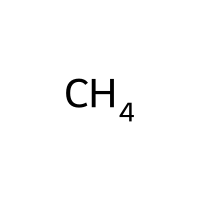
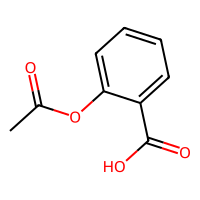
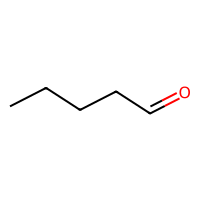
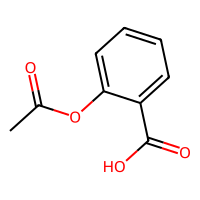
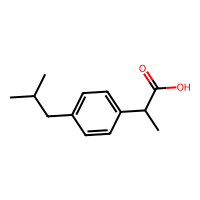
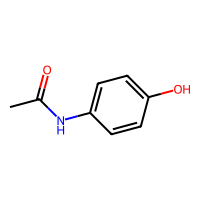
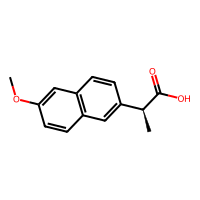
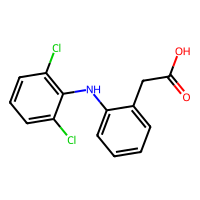
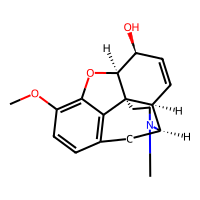
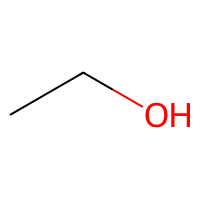
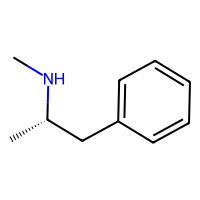
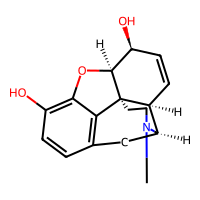
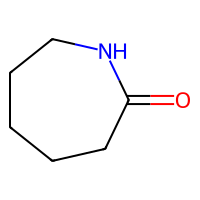
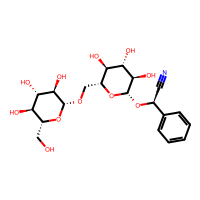
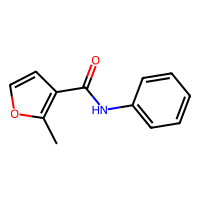
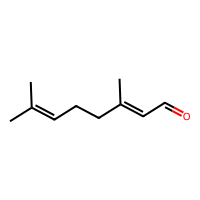
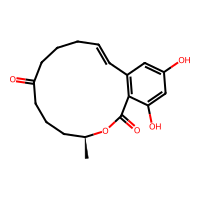
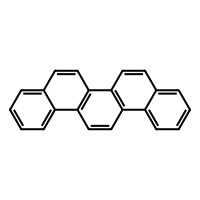
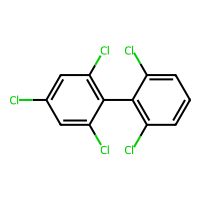
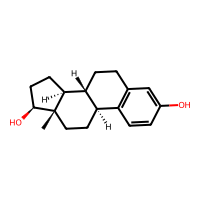
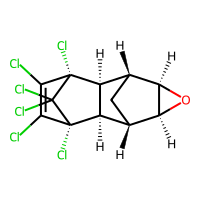
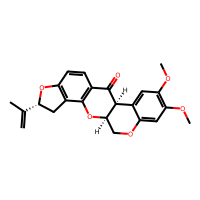
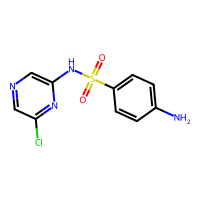
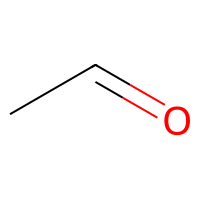
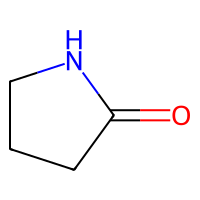
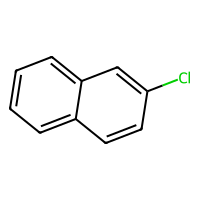
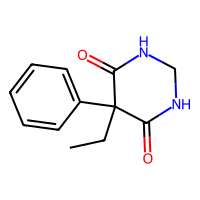
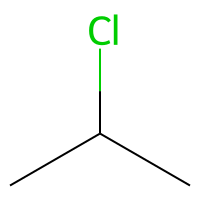
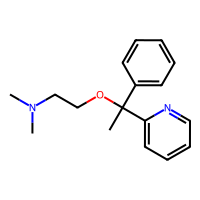
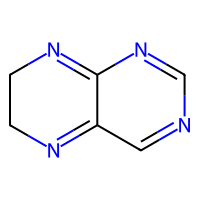
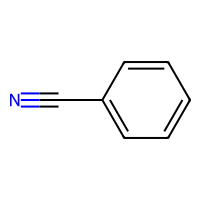
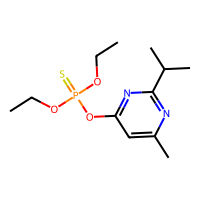
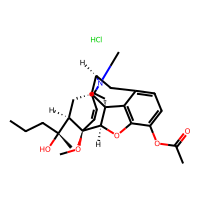
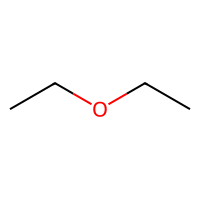
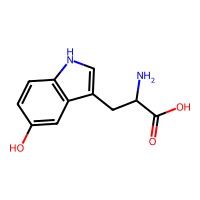
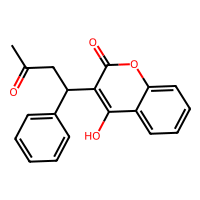
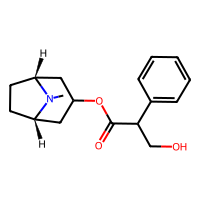
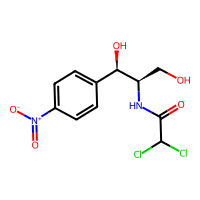
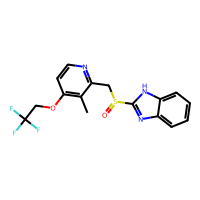
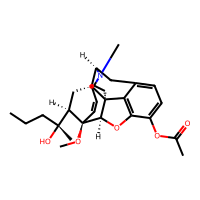
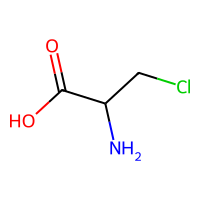
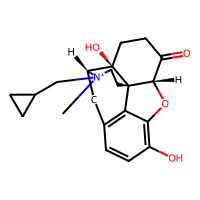
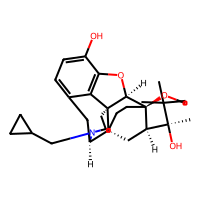
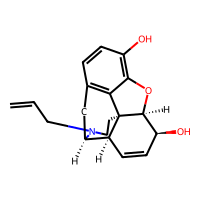

In [8]:
df2

## Calculation of Descriptors and Rules using map or apply

,Unnamed: 0,Name,CID,IUPAC_Name,Molecular_Formula,Molecular_Weight,SMILES,InChI,InChIKey,ROMol,FSP3
0,0,methane,297,methane,CH4,16.043,C,InChI=1S/CH4/h1H4,VNWKTOKETHGBQD-UHFFFAOYSA-N,,1.000000
1,1,2-acetyloxybenzoic acid,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N,,0.111111
2,2,pentanal,8063,pentanal,C5H10O,86.130,CCCCC=O,"InChI=1S/C5H10O/c1-2-3-4-5-6/h5H,2-4H2,1H3",HGBOYTHUEUWSSQ-UHFFFAOYSA-N,,0.800000
3,3,aspirin,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N,,0.111111
4,4,ibuprofen,3672,2-[4-(2-methylpropyl)phenyl]propanoic acid,C13H18O2,206.280,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,InChI=1S/C13H18O2/c1-9(2)8-11-4-6-12(7-5-11)10...,HEFNNWSXXWATRW-UHFFFAOYSA-N,,0.461538
5,5,paracetamol,1983,N-(4-hydroxyphenyl)acetamide,C8H9NO2,151.160,CC(=O)NC1=CC=C(C=C1)O,InChI=1S/C8H9NO2/c1-6(10)9-7-2-4-8(11)5-3-7/h2...,RZVAJINKPMORJF-UHFFFAOYSA-N,,0.125000
6,6,naproxen,156391,(2S)-2-(6-methoxynaphthalen-2-yl)propanoic acid,C14H14O3,230.260,C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O,InChI=1S/C14H14O3/c1-9(14(15)16)10-3-4-12-8-13...,CMWTZPSULFXXJA-VIFPVBQESA-N,,0.214286
7,7,diclofenac,3033,"2-[2-(2,6-dichloroanilino)phenyl]acetic acid",C14H11Cl2NO2,296.100,C1=CC=C(C(=C1)CC(=O)O)NC2=C(C=CC=C2Cl)Cl,InChI=1S/C14H11Cl2NO2/c15-10-5-3-6-11(16)14(10...,DCOPUUMXTXDBNB-UHFFFAOYSA-N,,0.071429
8,8,codeine,5284371,"(4R,4aR,7S,7aR,12bS)-9-methoxy-3-methyl-2,4,4a...",C18H21NO3,299.400,CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)OC)O[C...,InChI=1S/C18H21NO3/c1-19-8-7-18-11-4-5-13(20)1...,OROGSEYTTFOCAN-DNJOTXNNSA-N,,0.555556
9,9,ethanol,702,ethanol,C2H6O,46.070,CCO,"InChI=1S/C2H6O/c1-2-3/h3H,2H2,1H3",LFQSCWFLJHTTHZ-UHFFFAOYSA-N,,1.000000

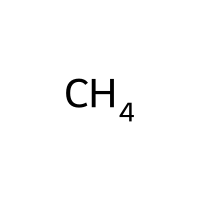
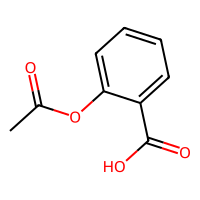
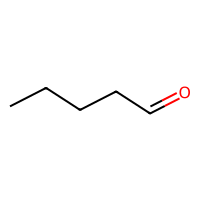
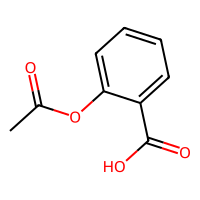
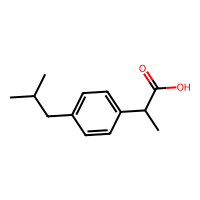
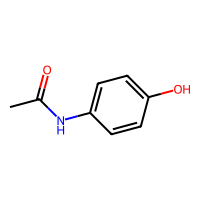
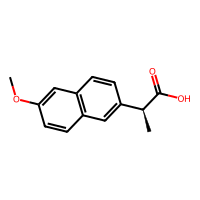
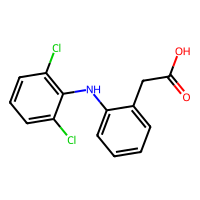
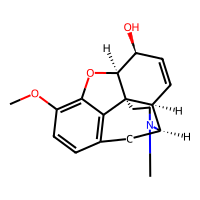
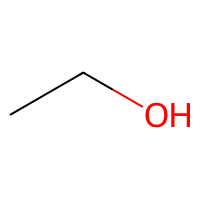
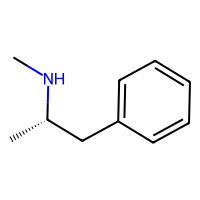
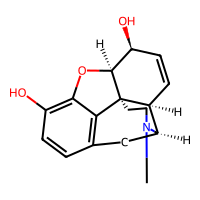
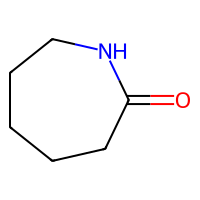
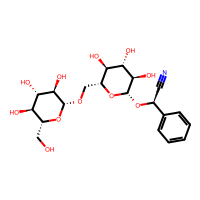
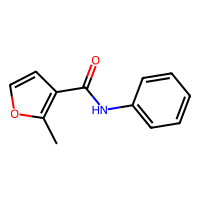
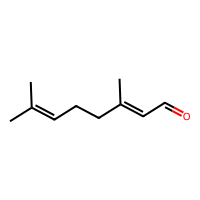
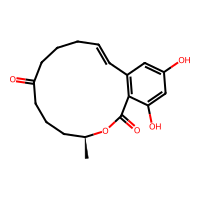
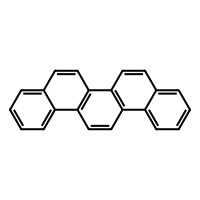
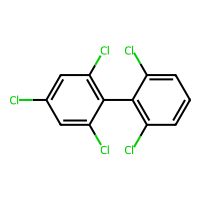
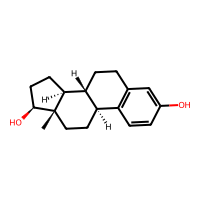
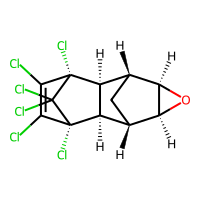
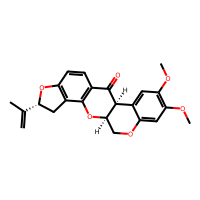
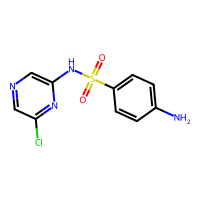
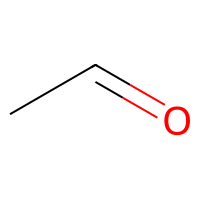
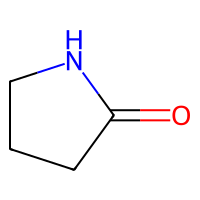
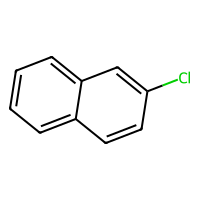
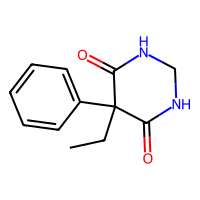
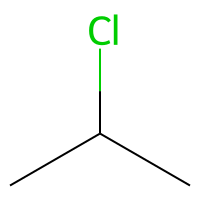
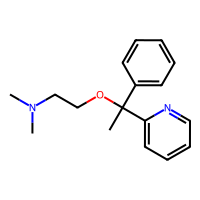
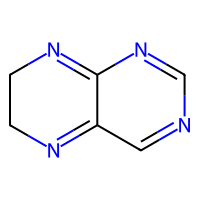
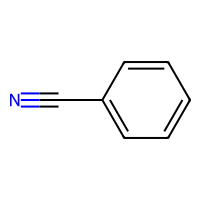
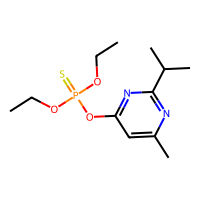
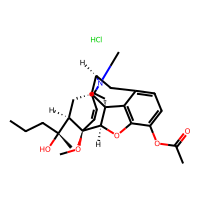
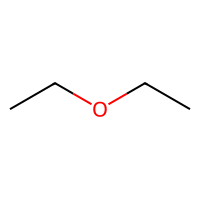
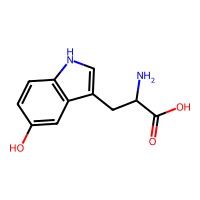
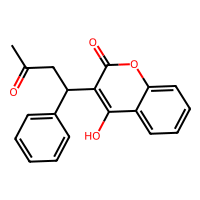
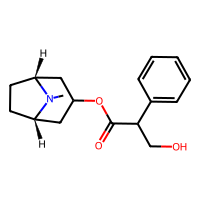
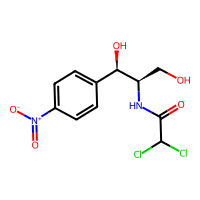
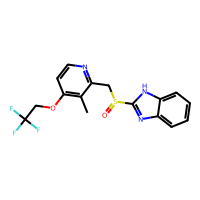
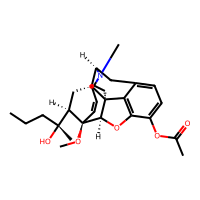
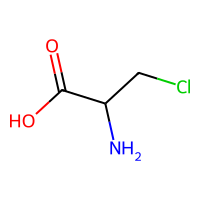
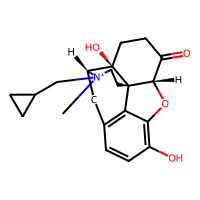
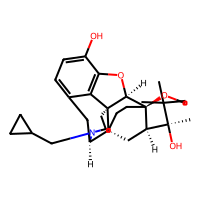
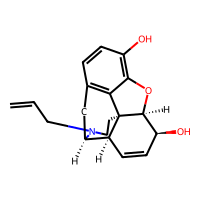

In [9]:
df2["FSP3"] = df2["ROMol"].map(Descriptors.FractionCSP3)
df2

In [10]:
def return_smarts(mol):
    return Chem.MolToSmarts(mol)

In [11]:
df2["SMARTS"] = df2["ROMol"].apply(return_smarts)

,Unnamed: 0,Name,CID,IUPAC_Name,Molecular_Formula,Molecular_Weight,SMILES,InChI,InChIKey,ROMol,FSP3,SMARTS
0,0,methane,297,methane,CH4,16.043,C,InChI=1S/CH4/h1H4,VNWKTOKETHGBQD-UHFFFAOYSA-N,,1.000000,[#6]
1,1,2-acetyloxybenzoic acid,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N,,0.111111,[#6]-[#6](=[#8])-[#8]-[#6]1:[#6]:[#6]:[#6]:[#6...
2,2,pentanal,8063,pentanal,C5H10O,86.130,CCCCC=O,"InChI=1S/C5H10O/c1-2-3-4-5-6/h5H,2-4H2,1H3",HGBOYTHUEUWSSQ-UHFFFAOYSA-N,,0.800000,[#6]-[#6]-[#6]-[#6]-[#6]=[#8]
3,3,aspirin,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N,,0.111111,[#6]-[#6](=[#8])-[#8]-[#6]1:[#6]:[#6]:[#6]:[#6...
4,4,ibuprofen,3672,2-[4-(2-methylpropyl)phenyl]propanoic acid,C13H18O2,206.280,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,InChI=1S/C13H18O2/c1-9(2)8-11-4-6-12(7-5-11)10...,HEFNNWSXXWATRW-UHFFFAOYSA-N,,0.461538,[#6]-[#6](-[#6])-[#6]-[#6]1:[#6]:[#6]:[#6](:[#...
5,5,paracetamol,1983,N-(4-hydroxyphenyl)acetamide,C8H9NO2,151.160,CC(=O)NC1=CC=C(C=C1)O,InChI=1S/C8H9NO2/c1-6(10)9-7-2-4-8(11)5-3-7/h2...,RZVAJINKPMORJF-UHFFFAOYSA-N,,0.125000,[#6]-[#6](=[#8])-[#7]-[#6]1:[#6]:[#6]:[#6](:[#...
6,6,naproxen,156391,(2S)-2-(6-methoxynaphthalen-2-yl)propanoic acid,C14H14O3,230.260,C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O,InChI=1S/C14H14O3/c1-9(14(15)16)10-3-4-12-8-13...,CMWTZPSULFXXJA-VIFPVBQESA-N,,0.214286,[#6]-[#6@@H](-[#6]1:[#6]:[#6]2:[#6](:[#6]:[#6]...
7,7,diclofenac,3033,"2-[2-(2,6-dichloroanilino)phenyl]acetic acid",C14H11Cl2NO2,296.100,C1=CC=C(C(=C1)CC(=O)O)NC2=C(C=CC=C2Cl)Cl,InChI=1S/C14H11Cl2NO2/c15-10-5-3-6-11(16)14(10...,DCOPUUMXTXDBNB-UHFFFAOYSA-N,,0.071429,[#6]1:[#6]:[#6]:[#6](:[#6](:[#6]:1)-[#6]-[#6](...
8,8,codeine,5284371,"(4R,4aR,7S,7aR,12bS)-9-methoxy-3-methyl-2,4,4a...",C18H21NO3,299.400,CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)OC)O[C...,InChI=1S/C18H21NO3/c1-19-8-7-18-11-4-5-13(20)1...,OROGSEYTTFOCAN-DNJOTXNNSA-N,,0.555556,[#6]-[#7]1-[#6]-[#6]-[#6@]23-[#6@@H]4-[#6@H]-1...
9,9,ethanol,702,ethanol,C2H6O,46.070,CCO,"InChI=1S/C2H6O/c1-2-3/h3H,2H2,1H3",LFQSCWFLJHTTHZ-UHFFFAOYSA-N,,1.000000,[#6]-[#6]-[#8]

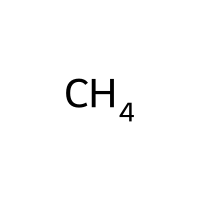
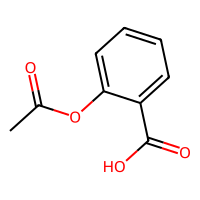
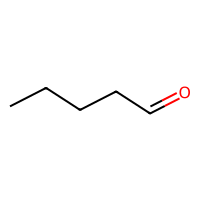
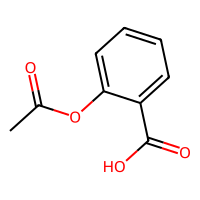
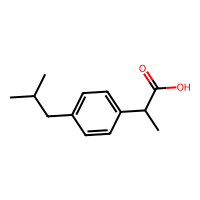
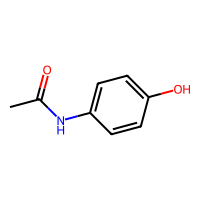
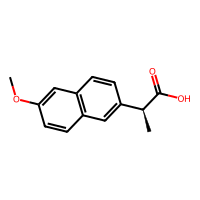
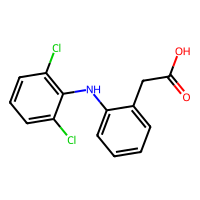
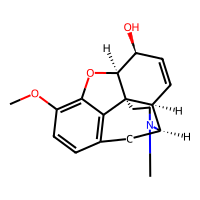
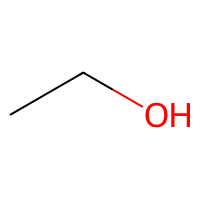
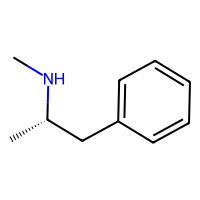
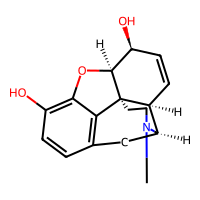
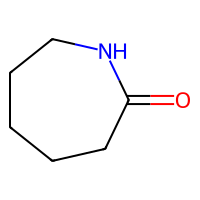
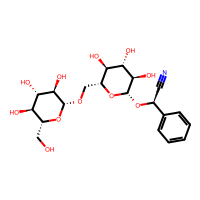
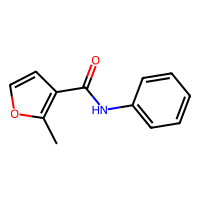
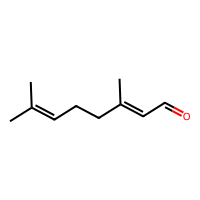
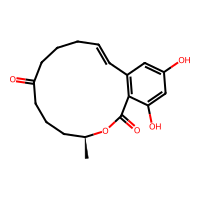
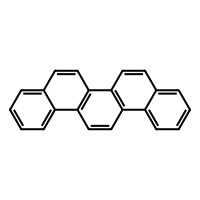
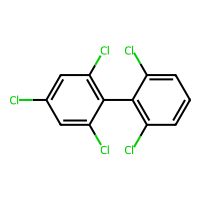
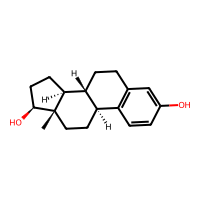
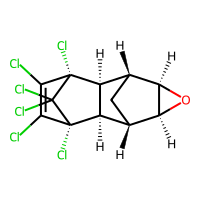
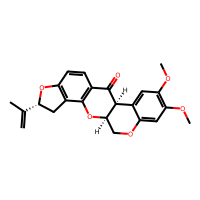
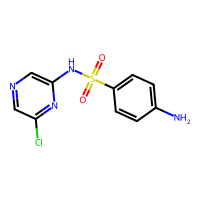
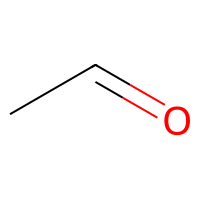
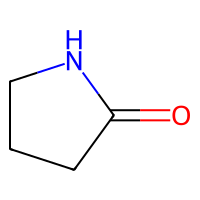
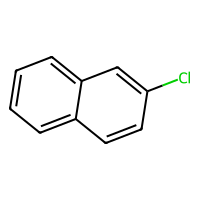
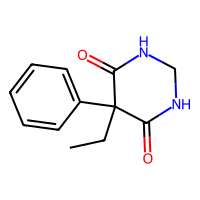
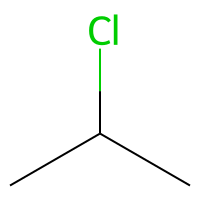
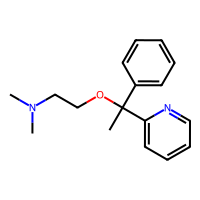
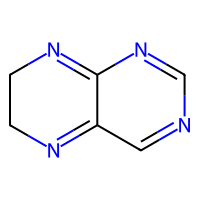
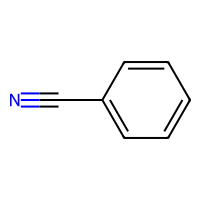
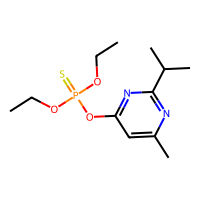
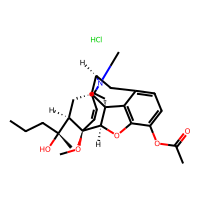
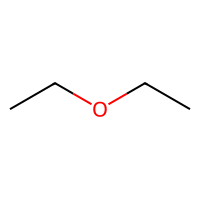
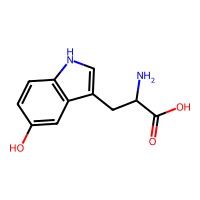
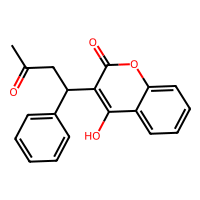
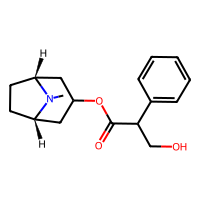
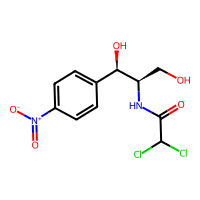
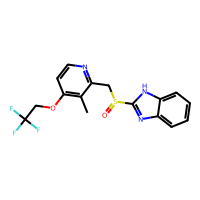
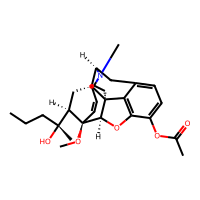
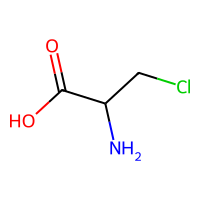
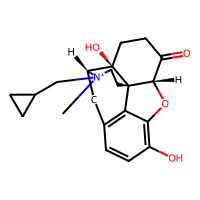
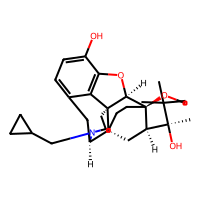
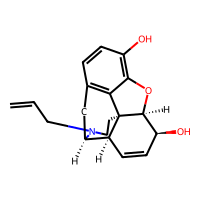

In [12]:
df2

## Substructure Search
#### - using GE or >= operator

,Unnamed: 0,Name,CID,IUPAC_Name,Molecular_Formula,Molecular_Weight,SMILES,InChI,InChIKey,ROMol,FSP3,SMARTS
0,0,methane,297,methane,CH4,16.043,C,InChI=1S/CH4/h1H4,VNWKTOKETHGBQD-UHFFFAOYSA-N,,1.000000,[#6]
1,1,2-acetyloxybenzoic acid,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N,,0.111111,[#6]-[#6](=[#8])-[#8]-[#6]1:[#6]:[#6]:[#6]:[#6...
2,2,pentanal,8063,pentanal,C5H10O,86.130,CCCCC=O,"InChI=1S/C5H10O/c1-2-3-4-5-6/h5H,2-4H2,1H3",HGBOYTHUEUWSSQ-UHFFFAOYSA-N,,0.800000,[#6]-[#6]-[#6]-[#6]-[#6]=[#8]
3,3,aspirin,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N,,0.111111,[#6]-[#6](=[#8])-[#8]-[#6]1:[#6]:[#6]:[#6]:[#6...
4,4,ibuprofen,3672,2-[4-(2-methylpropyl)phenyl]propanoic acid,C13H18O2,206.280,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,InChI=1S/C13H18O2/c1-9(2)8-11-4-6-12(7-5-11)10...,HEFNNWSXXWATRW-UHFFFAOYSA-N,,0.461538,[#6]-[#6](-[#6])-[#6]-[#6]1:[#6]:[#6]:[#6](:[#...
5,5,paracetamol,1983,N-(4-hydroxyphenyl)acetamide,C8H9NO2,151.160,CC(=O)NC1=CC=C(C=C1)O,InChI=1S/C8H9NO2/c1-6(10)9-7-2-4-8(11)5-3-7/h2...,RZVAJINKPMORJF-UHFFFAOYSA-N,,0.125000,[#6]-[#6](=[#8])-[#7]-[#6]1:[#6]:[#6]:[#6](:[#...
6,6,naproxen,156391,(2S)-2-(6-methoxynaphthalen-2-yl)propanoic acid,C14H14O3,230.260,C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O,InChI=1S/C14H14O3/c1-9(14(15)16)10-3-4-12-8-13...,CMWTZPSULFXXJA-VIFPVBQESA-N,,0.214286,[#6]-[#6@@H](-[#6]1:[#6]:[#6]2:[#6](:[#6]:[#6]...
7,7,diclofenac,3033,"2-[2-(2,6-dichloroanilino)phenyl]acetic acid",C14H11Cl2NO2,296.100,C1=CC=C(C(=C1)CC(=O)O)NC2=C(C=CC=C2Cl)Cl,InChI=1S/C14H11Cl2NO2/c15-10-5-3-6-11(16)14(10...,DCOPUUMXTXDBNB-UHFFFAOYSA-N,,0.071429,[#6]1:[#6]:[#6]:[#6](:[#6](:[#6]:1)-[#6]-[#6](...
8,8,codeine,5284371,"(4R,4aR,7S,7aR,12bS)-9-methoxy-3-methyl-2,4,4a...",C18H21NO3,299.400,CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)OC)O[C...,InChI=1S/C18H21NO3/c1-19-8-7-18-11-4-5-13(20)1...,OROGSEYTTFOCAN-DNJOTXNNSA-N,,0.555556,[#6]-[#7]1-[#6]-[#6]-[#6@]23-[#6@@H]4-[#6@H]-1...
9,9,ethanol,702,ethanol,C2H6O,46.070,CCO,"InChI=1S/C2H6O/c1-2-3/h3H,2H2,1H3",LFQSCWFLJHTTHZ-UHFFFAOYSA-N,,1.000000,[#6]-[#6]-[#8]

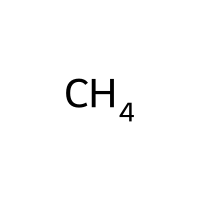
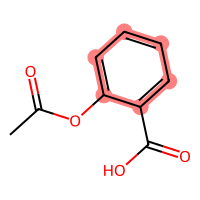
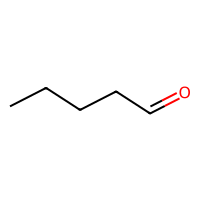
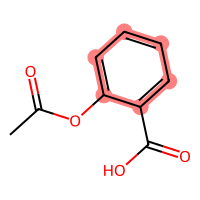
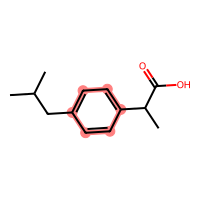
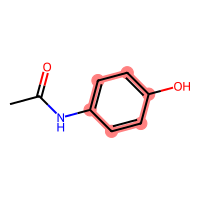
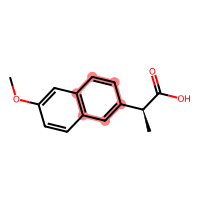
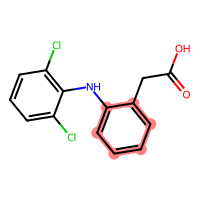
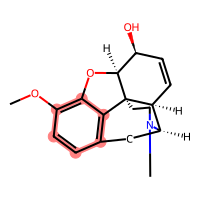
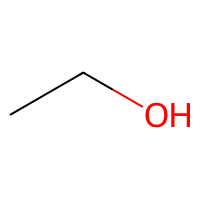
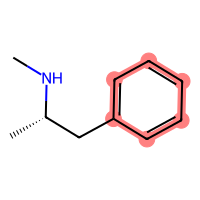
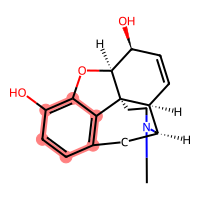
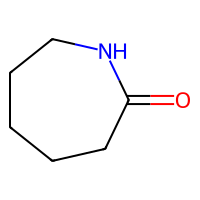
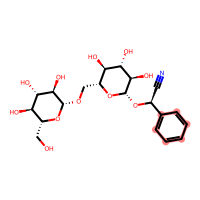
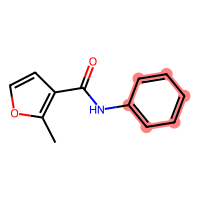
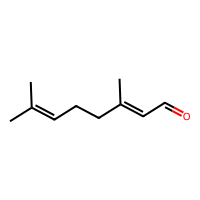
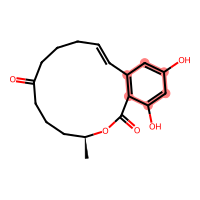
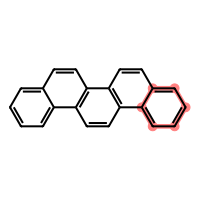
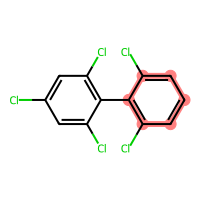
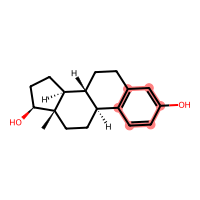
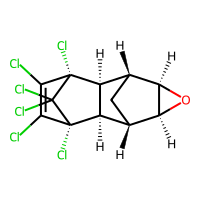
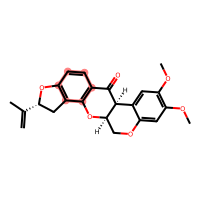
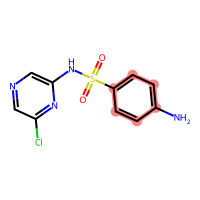
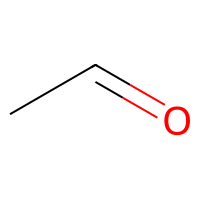
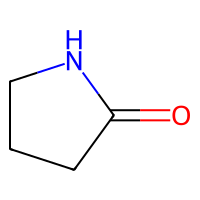
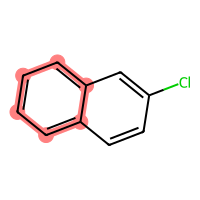
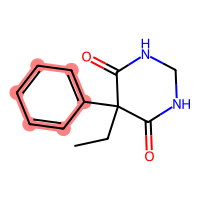
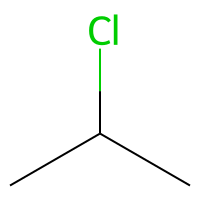
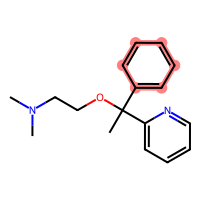
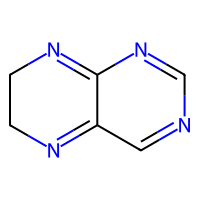
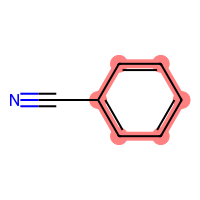
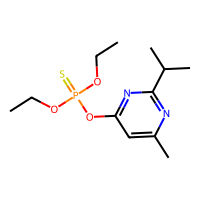
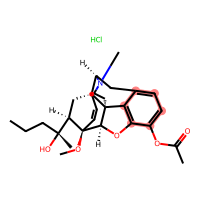
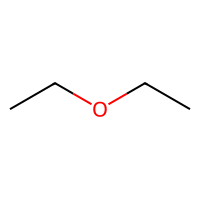
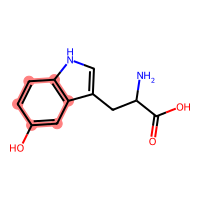
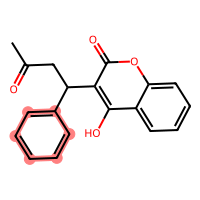
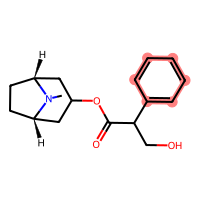
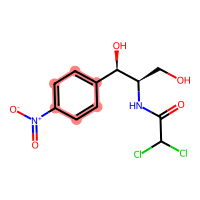
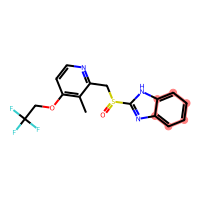
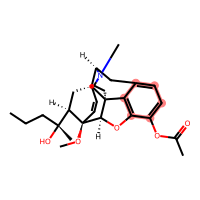
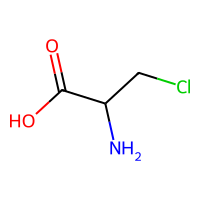
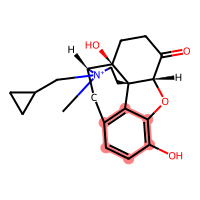
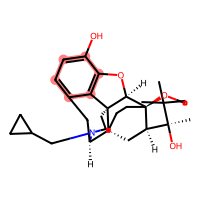
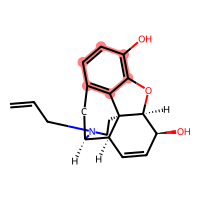

In [13]:
c6h6 = Chem.MolFromSmiles("c1ccccc1")
df2[df2.ROMol >= c6h6]
df2

___________________________________________

___________________________________________

## Building a Dataset  

In [14]:
silico = pd.read_csv("silico_dataset.csv")
silico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    520 non-null    object
 1   SMILES  520 non-null    object
dtypes: object(2)
memory usage: 8.3+ KB


In [15]:
silico

,Name,SMILES
0,methylthiouracil,Cc1cc(=O)[nH]c(=S)[nH]1
1,Eugenol,COc1cc(CC=C)ccc1O
2,5-Allyl-5-isopropylbarbital,O=C1NC(=O)NC(=O)C1(C(C)C)CC=C
3,Pyrene,c1cc2ccc3cccc4ccc(c1)c2c34
4,"1,1-Diethoxyethane",CCOC(C)OCC
...,...,...
515,Acetorphine,CCC[C@](C)([C@H]1C[C@@]23C=C[C@@]1([C@H]4[C@@]...
516,3-Chloroalanine,C(C(C(=O)O)N)Cl
517,Methylnaltrexone,C[N+]1(CC[C@]23[C@@H]4C(=O)CC[C@]2([C@H]1CC5=C...
518,Buprenorphine,C[C@]([C@H]1C[C@@]23CC[C@@]1([C@H]4[C@@]25CCN(...


#### - Creating Mol Objects

In [16]:
PandasTools.AddMoleculeColumnToFrame(silico, "SMILES")

,Name,SMILES,ROMol
0,methylthiouracil,Cc1cc(=O)[nH]c(=S)[nH]1,
1,Eugenol,COc1cc(CC=C)ccc1O,
2,5-Allyl-5-isopropylbarbital,O=C1NC(=O)NC(=O)C1(C(C)C)CC=C,
3,Pyrene,c1cc2ccc3cccc4ccc(c1)c2c34,
4,"1,1-Diethoxyethane",CCOC(C)OCC,
...,...,...,...
515,Acetorphine,CCC[C@](C)([C@H]1C[C@@]23C=C[C@@]1([C@H]4[C@@]...,
516,3-Chloroalanine,C(C(C(=O)O)N)Cl,
517,Methylnaltrexone,C[N+]1(CC[C@]23[C@@H]4C(=O)CC[C@]2([C@H]1CC5=C...,
518,Buprenorphine,C[C@]([C@H]1C[C@@]23CC[C@@]1([C@H]4[C@@]25CCN(...,

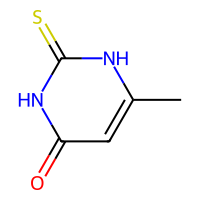
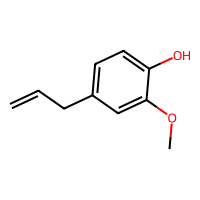
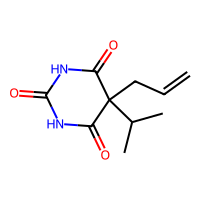
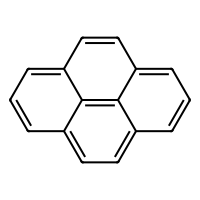
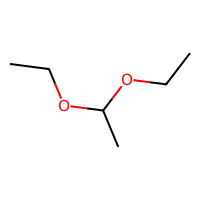
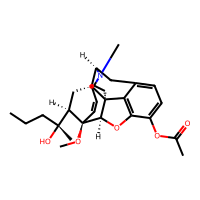
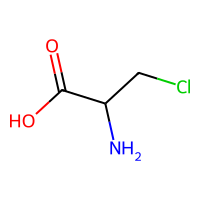
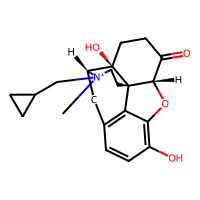
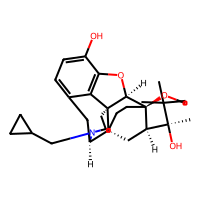
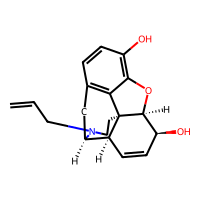

In [17]:
silico

####  - Calculation of Descriptors

In [18]:
silico["Molecular_Weight"] = silico["ROMol"].map(Descriptors.MolWt)
silico["LogP"] = silico["ROMol"].map(Descriptors.MolLogP)
silico["Num_H_Donors"] = silico["ROMol"].map(Descriptors.NumHDonors)
silico["Num_H_Acceptors"] = silico["ROMol"].map(Descriptors.NumHAcceptors)
silico["TPSA"] = silico["ROMol"].map(Descriptors.TPSA)
silico["FCSP3"] = silico["ROMol"].map(Descriptors.FractionCSP3)

,Name,SMILES,ROMol,Molecular_Weight,LogP,Num_H_Donors,Num_H_Acceptors,TPSA,FCSP3
0,methylthiouracil,Cc1cc(=O)[nH]c(=S)[nH]1,,142.183,0.74091,2,2,48.65,0.200000
1,Eugenol,COc1cc(CC=C)ccc1O,,164.204,2.12930,1,2,29.46,0.200000
2,5-Allyl-5-isopropylbarbital,O=C1NC(=O)NC(=O)C1(C(C)C)CC=C,,210.233,0.57090,2,3,75.27,0.500000
3,Pyrene,c1cc2ccc3cccc4ccc(c1)c2c34,,202.256,4.58400,0,0,0.00,0.000000
4,"1,1-Diethoxyethane",CCOC(C)OCC,,118.176,1.40540,0,2,18.46,1.000000
...,...,...,...,...,...,...,...,...,...
515,Acetorphine,CCC[C@](C)([C@H]1C[C@@]23C=C[C@@]1([C@H]4[C@@]...,,453.579,3.38330,1,6,68.23,0.666667
516,3-Chloroalanine,C(C(C(=O)O)N)Cl,,123.539,-0.36290,2,2,63.32,0.666667
517,Methylnaltrexone,C[N+]1(CC[C@]23[C@@H]4C(=O)CC[C@]2([C@H]1CC5=C...,,356.442,1.67000,2,4,66.76,0.666667
518,Buprenorphine,C[C@]([C@H]1C[C@@]23CC[C@@]1([C@H]4[C@@]25CCN(...,,467.650,4.41380,2,5,62.16,0.793103

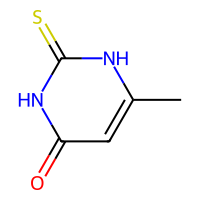
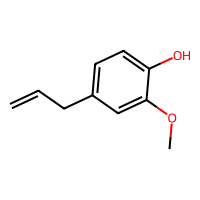
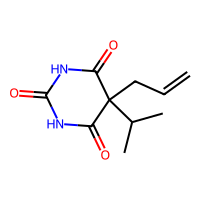
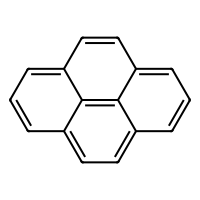
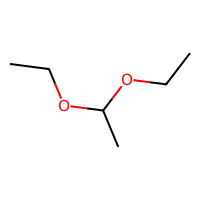
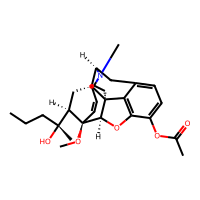
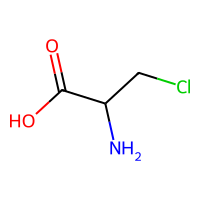
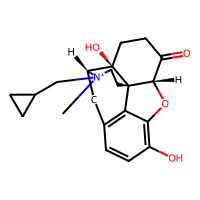
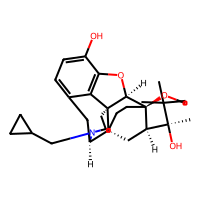
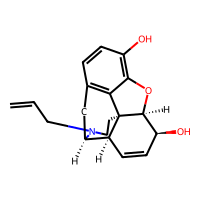

In [19]:
silico

#### - Applying Rules to the Dataset

In [20]:
def lipinski_RO5(mol):

    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    
    satisfies_ro5 = (mw <= 500) and (logp <= 5) and (hbd <= 5) and (hba <= 10)
    
    return str(satisfies_ro5)

In [21]:
def pfizer_3_75(mol):

    logP = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    
    if logP > 3 and tpsa < 75:
        result = "toxic"
    else:
        result = "not toxic"
    
    return result

In [22]:
def has_benzene(smiles):
    
    benzene = "c1ccccc1"
    benzene_pattern = Chem.MolFromSmiles(benzene)
    mol = Chem.MolFromSmiles(smiles)
    return str(mol.HasSubstructMatch(benzene_pattern))

In [23]:
silico["Lipinski_RO5"] = silico["ROMol"].apply(lipinski_RO5)
silico["Pfizer_3/75"] = silico["ROMol"].apply(pfizer_3_75)

In [24]:
silico["Has_Benzene"] = silico["SMILES"].apply(has_benzene)

,Name,SMILES,ROMol,Molecular_Weight,LogP,Num_H_Donors,Num_H_Acceptors,TPSA,FCSP3,Lipinski_RO5,Pfizer_3/75,Has_Benzene
0,methylthiouracil,Cc1cc(=O)[nH]c(=S)[nH]1,,142.183,0.74091,2,2,48.65,0.200000,True,not toxic,False
1,Eugenol,COc1cc(CC=C)ccc1O,,164.204,2.12930,1,2,29.46,0.200000,True,not toxic,True
2,5-Allyl-5-isopropylbarbital,O=C1NC(=O)NC(=O)C1(C(C)C)CC=C,,210.233,0.57090,2,3,75.27,0.500000,True,not toxic,False
3,Pyrene,c1cc2ccc3cccc4ccc(c1)c2c34,,202.256,4.58400,0,0,0.00,0.000000,True,toxic,True
4,"1,1-Diethoxyethane",CCOC(C)OCC,,118.176,1.40540,0,2,18.46,1.000000,True,not toxic,False
...,...,...,...,...,...,...,...,...,...,...,...,...
515,Acetorphine,CCC[C@](C)([C@H]1C[C@@]23C=C[C@@]1([C@H]4[C@@]...,,453.579,3.38330,1,6,68.23,0.666667,True,toxic,True
516,3-Chloroalanine,C(C(C(=O)O)N)Cl,,123.539,-0.36290,2,2,63.32,0.666667,True,not toxic,False
517,Methylnaltrexone,C[N+]1(CC[C@]23[C@@H]4C(=O)CC[C@]2([C@H]1CC5=C...,,356.442,1.67000,2,4,66.76,0.666667,True,not toxic,True
518,Buprenorphine,C[C@]([C@H]1C[C@@]23CC[C@@]1([C@H]4[C@@]25CCN(...,,467.650,4.41380,2,5,62.16,0.793103,True,toxic,True

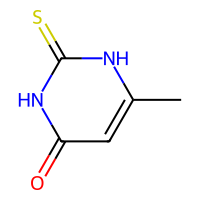
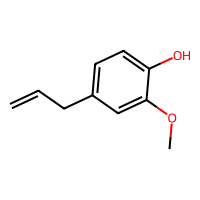
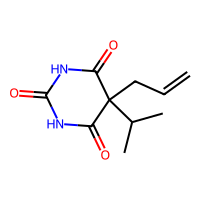
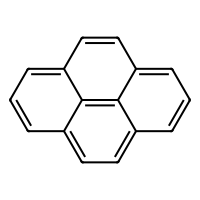
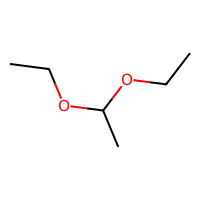
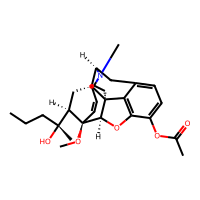
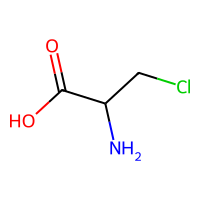
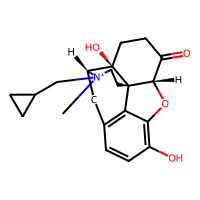
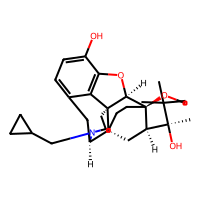
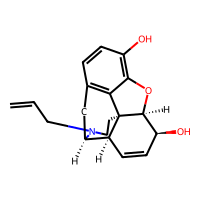

In [25]:
silico

#### - Write SDF

In [26]:
PandasTools.WriteSDF(silico, "new_silico.sdf", molColName = "ROMol", idName = "Name", properties = list(silico.columns))

#### - Saving the Dataset

In [27]:
pip install XlsxWriter


  Using cached XlsxWriter-3.2.0-py3-none-any.whl.metadata (2.6 kB)
Using cached XlsxWriter-3.2.0-py3-none-any.whl (159 kB)


In [28]:
PandasTools.SaveXlsxFromFrame(silico, "new_silico_dataset.xlsx", molCol = "ROMol", size = (150, 150))